# 05 · Language World Models for coding agents (AgentWorld)

This is the centerpiece. From *Qwen-AgentWorld: Language World Models for General Agents* (2026): a
**world model** predicts the next **observation** given history + action. Episodic already captures
exactly those `(action -> observation)` pairs, so it is a data factory for a *coding* world model.

We implement and demonstrate, model-free:
1. trajectory → turn expansion
2. the Echo-Trap one-turn-per-trajectory RL pool
3. OOD split by data-source
4. the `wm` SFT export (assistant = observation)
5. **EpisodicWorldBench** with content-type fidelity
6. double-blind **Turing-test** judge calibration
7. the **hybrid** rule + rubric judge

In [1]:
from episodic import worldmodel
from episodic.testing import make_episode

ep = make_episode("ep_wm", intent="add retry to http client", files=("src/http.py",))
samples = worldmodel.expand_turns(ep)
print("turns in episode:", len(ep["steps"]), "-> prediction samples:", len(samples))
s = samples[-1]
print("\n--- one world-model sample (history+action -> observation) ---")
print(s["history"][:300])
print("TARGET OBSERVATION:", repr(s["target_observation"][:80]))

turns in episode: 3 -> prediction samples: 2

--- one world-model sample (history+action -> observation) ---
INTENT: add retry to http client
ACTION: user_prompt: add retry to http client
OBSERVATION: 
ACTION: Edit({"file_path": "src/http.py"}) @ /repo
OBSERVATION: applied edit to src/http.py
ACTION: Bash({"command": "pytest -q"}) @ /repo
OBSERVATION:
TARGET OBSERVATION: '============================= test session starts =============================\n'


**Echo-Trap fix:** expanding every turn yields long shared prefixes that collapse RL reward variance. The RL pool keeps exactly one turn per trajectory:

In [2]:
from episodic.testing import make_population
pop = make_population(40, seed=1, sources=[f"repo-{i}" for i in range(8)])
all_turns = worldmodel.wm_samples(pop, one_per_trajectory=False)
rl_pool   = worldmodel.wm_samples(pop, one_per_trajectory=True, seed=0)
print("all turns:", len(all_turns), "| one-per-trajectory RL pool:", len(rl_pool), "(== #episodes:", len(pop), ")")

all turns: 100 | one-per-trajectory RL pool: 40 (== #episodes: 40 )


**OOD split by data-source** (AgentWorld principle iv): partition by repo so the benchmark probes generalization, not memorization. Train/holdout sources are disjoint:

In [3]:
train, holdout, mapping = worldmodel.ood_split(pop, holdout_frac=0.4, seed=7)
train_src = {worldmodel.source_key(e) for e in train}
hold_src = {worldmodel.source_key(e) for e in holdout}
print("train sources:", sorted(train_src))
print("holdout sources:", sorted(hold_src))
print("disjoint:", train_src.isdisjoint(hold_src))

train sources: ['repo-1', 'repo-2', 'repo-3', 'repo-4', 'repo-6', 'repo-7']
holdout sources: ['repo-0', 'repo-5']
disjoint: True


## EpisodicWorldBench

Score a predictor's next-observation prediction with content-type fidelity. We compare baselines:
`oracle` (returns truth), `prefix` (copies the previous observation), `empty`. A real model plugs in
via `episodic worldbench --cmd '<your-model> {prompt_file}' --execute`.

In [4]:
from episodic import worldbench
import pandas as pd
rows = []
for name in ["oracle", "prefix", "echo", "empty"]:
    overall = worldbench.run_bench(pop, name)["overall"]
    rows.append({"predictor": name, **{d: overall[d] for d in ["factuality", "realism", "composite"]}})
pd.DataFrame(rows).set_index("predictor")

,factuality,realism,composite
predictor,,,
oracle,1.00,1.000,1.0000
prefix,0.15,0.375,0.2894
echo,0.00,0.825,0.3099
empty,0.00,0.000,0.1000


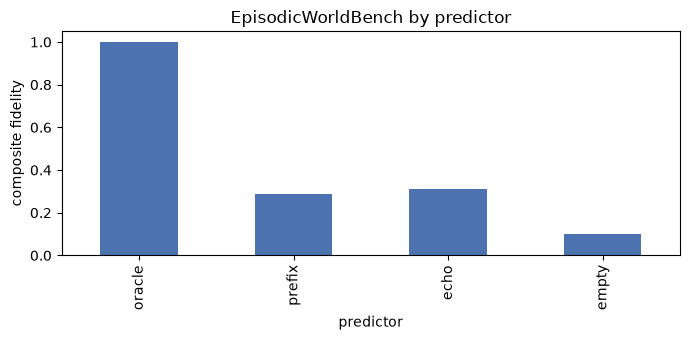

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
df = pd.DataFrame(rows).set_index("predictor")
ax = df[["composite"]].plot(kind="bar", legend=False, figsize=(7, 3.5), color="#4c72b0")
ax.set_ylim(0, 1.05); ax.set_ylabel("composite fidelity"); ax.set_title("EpisodicWorldBench by predictor")
plt.tight_layout(); plt.show()

**Turing-test calibration** (AgentWorld §4.2): a discriminator tries to tell real observations from predicted ones. `indistinguishability ≈ 1` means it cannot — a perfect world model. The oracle is indistinguishable; `empty` is obvious:

In [6]:
for name in ["oracle", "prefix", "empty"]:
    t = worldbench.turing_test(pop, name)
    print(f"{name:<8} discriminator_accuracy={t['discriminator_accuracy']:.2f}  indistinguishability={t['indistinguishability']:.2f}")

oracle   discriminator_accuracy=0.50  indistinguishability=1.00
prefix   discriminator_accuracy=0.78  indistinguishability=0.45
empty    discriminator_accuracy=0.78  indistinguishability=0.45


**Hybrid rule + rubric reward** (AgentWorld §3.4.1): blend the rule-based fidelity with an optional LLM-judge. Here a stand-in judge; in production pass an Anthropic/OpenAI judge that returns per-dimension scores.

In [7]:
def stub_rubric_judge(predicted, target):
    # A real judge returns {Factuality, Consistency, ...} in [0,1]; here a length-aware stand-in.
    ratio = min(len(predicted), len(target)) / max(1, len(target))
    return {"factuality": round(ratio, 3), "quality": round(ratio, 3)}

rule = worldbench.run_bench(pop, "prefix")["overall"]["composite"]
hybrid = worldbench.run_bench(pop, "prefix", judge=stub_rubric_judge, judge_weight=0.5)["overall"]["composite"]
print("rule-only composite :", rule)
print("hybrid   composite :", hybrid)

rule-only composite : 0.2894
hybrid   composite : 0.3072


## Where this goes

- Export `wm` and train a coding world model with `trl-sft` (the assistant turn is the observation).
- Use it as a **decoupled simulator**: `episodic worldbench --cmd` points the bench at your model;
  the same predictor interface can drive *simulated* replay-eval — cheaper than cloning + running.
- **Agent–LWM co-evolution**: captured sessions → train WM → WM generates harder scenarios → agent
  improves → more captures. Episodic closes that loop.